In [1]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import igraph as ig
from matplotlib import pyplot as plt
import time
from ucimlrepo import fetch_ucirepo

from sklearn.metrics import euclidean_distances
import os

In [2]:
def LLGC(X, Y, media, amostras):
    # 1. Calcular a variância (Sigma^2)
    varianca = np.sum((X - media)**2) / amostras

    # 2. Calcular a matriz de afinidade W (RBF Kernel)
    dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :])**2, axis=2)
    W = np.exp(-dist_sq / (2 * varianca))
    np.fill_diagonal(W, 0)

    # 3. Calcular a matriz de normalização simétrica S
    d = W.sum(axis=1)
    # Usar 1e-12 para evitar divisões por zero em pontos isolados
    d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    S = D_inv_sqrt @ W @ D_inv_sqrt

    # 4. Calcular a matriz identidade
    I = np.eye(X.shape[0])

    # 5. Calcular a matriz de saída F (Forma Fechada)
    F = 0.1 * np.linalg.solve(I - 0.9 * S, Y)

    # 6. Determinar a classe prevista
    result = np.argmax(F, axis=1)

    return F, result

In [3]:
def map_classes(y):
    # realiza o mapeamento das classes e suas posicoes no vetor. necessario pois ha datasets que nao tem todas as classes de forma sequencial
    # ex. set(y) = [1,2,3,6,8] ao inves de [0,1,2,3,4] 
    class_map = {}
    for id,clas in enumerate(np.unique(y)):
        print(clas)
        class_map[id] = clas
    # Invertendo o dicionário para mapeamento de valores para chaves
    inverse_dic = {v: k for k, v in class_map.items()}
    
    # Substituindo os valores no vetor pelas chaves do dicionário
    # assim o vetor y tera classes de 0 a n, o que nao ocorre em todas os datasets
    y = np.array([inverse_dic[val] for val in y])
    
    return y

# Dados

## Heart - 2 classes

0
1
2
3
4


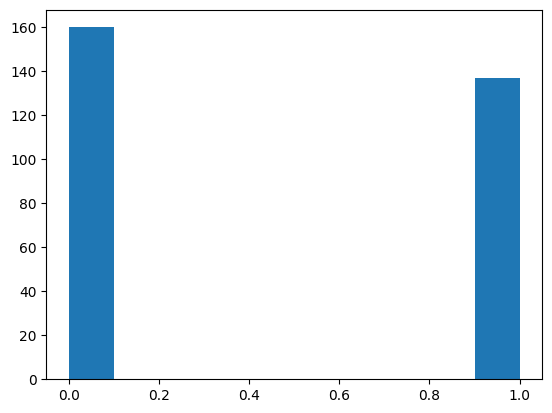

In [4]:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features

rows_without_nan = ~X.isna().any(axis=1)
X = X.dropna().to_numpy()
y = heart_disease.data.targets.to_numpy().flatten()[rows_without_nan]

base = 'heart'

index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

# Alterar as classes 1, 2, 3 e 4 para 1
y = np.where((y >= 1) & (y <= 4), 1, y)

transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


heart = (X,y)
plt.hist(y)
plt.show()

In [5]:
# fetch dataset
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151)

# data (as pandas dataframes)
X = connectionist_bench_sonar_mines_vs_rocks.data.features.to_numpy()
y = connectionist_bench_sonar_mines_vs_rocks.data.targets.to_numpy().flatten()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

base = 'sonar'
index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


sonar = (X,y)


0
1


In [6]:
# In[musk_v1]
from ucimlrepo import fetch_ucirepo

# # fetch dataset
# musk_version_1 = fetch_ucirepo(id=74)
# musk_version_1.data.features.drop('conformation_name', axis=1, inplace=True)
# musk_version_1.data.features.drop('molecule_name', axis=1, inplace=True)
#
# # data (as pandas dataframes)
# X = musk_version_1.data.features.to_numpy()
# y = musk_version_1.data.targets.to_numpy().flatten()

#############################################################################
# fetch dataset
musk_version_1 = fetch_ucirepo(id=74)

# Criar uma cópia explícita das features para evitar o warning
X_df = musk_version_1.data.features.copy()

# Agora você pode remover as colunas sem problemas
X_df.drop(['conformation_name', 'molecule_name'], axis=1, inplace=True)

# data (as pandas dataframes)
X = X_df.to_numpy()
y = musk_version_1.data.targets.to_numpy().flatten()
###########################################################################

base = 'musk_v1'
index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


musk = (X,y)


0.0
1.0


In [7]:
datasets = [
    heart,
    musk,
    sonar,
]

datasets_name = [
    'heart',
    'musk',
    'sonar'
]

In [8]:
# Função para converter a árvore em um grafo do igraph
def tree_to_igraph(tree):
    edges = []
    node_counter = 0
    clade_to_id = {}
    clade_names = {}
    weights = []
        

    for clade in tree.traverse("levelorder"):
    # for clade in tree.find_clades(order="level"):
        if clade not in clade_to_id:
            clade_name = clade.name if clade.name else f"node_{node_counter}"
            clade_to_id[clade] = node_counter
            clade_names[node_counter] = clade_name
            node_counter += 1
        for child in clade.children:
        # for child in clade.clades:
            if child not in clade_to_id:
                child_name = child.name if child.name else f"node_{node_counter}"
                clade_to_id[child] = node_counter
                clade_names[node_counter] = child_name
                node_counter += 1
            edges.append((clade_to_id[clade], clade_to_id[child]))
            # print(clade.branch_length, child.branch_length)
            # print(clade_to_id[clade], clade_to_id[child])
            # print(clade_names[clade_to_id[clade]], clade_names[clade_to_id[child]])
            # testar com clade.branch_length e com 1/child.branch_lenght
            # weights.append(clade.branch_length or 1.0)
            
            weights.append(1/child.dist if child.dist is not None and child.dist != 0.0 else 0.000001)
            
            # try:
            #     weights.append(child.branch_length)
            # except:
            #     weights.append(0.0)
    
    # print("Edges:", edges)  # Adiciona instrução de depuração
    # print("Clade Names:", clade_names)  # Adiciona instrução de depuração
    g = ig.Graph(edges=edges)
    g.vs["name"] = [clade_names[i] for i in range(len(clade_names))]
    g.vs["label"] = [clade_names[i] for i in range(len(clade_names))]
    g.es["weights"] = weights
    return g

In [9]:
def configurar_Y(amostras, y, qnt, num_classes):
    # Inicializar a matriz Y com zeros
    Y = np.zeros((amostras, num_classes))

    # Calcular a quantidade de amostras a serem rotuladas por classe
    qntAmostrasPorClasse = qnt
    # print(f'qnt por classe: {qntAmostrasPorClasse} amostras: {amostras} num_c: {num_classes} qnt: {qnt}' )

    # Criar um conjunto de índices disponíveis
    indices_disponiveis = set(range(amostras))

    for classe in range(num_classes):
        # Obter índices de todas as amostras da classe atual
        indices_classe = set(np.where(y == classe)[0])

        # Obter a interseção de índices disponíveis e índices da classe
        indices_classe_disponiveis = list(indices_classe & indices_disponiveis)
        
        # Selecionar aleatoriamente amostras a serem rotuladas para a classe atual
        indices_rotulados = np.random.choice(indices_classe_disponiveis, qntAmostrasPorClasse, replace=False)

        # Atribuir rótulos às amostras selecionadas
        Y[indices_rotulados, classe] = 1

        # Remover os índices selecionados do conjunto de disponíveis
        indices_disponiveis -= set(indices_rotulados)

    return Y

In [10]:
def experiment(X, y, grupos, qntAmostrasPorClasse = 1, num_exec = 30):
    media=X.mean(axis=0)
    accuracy_own = []
    accuracy_llgc = []
    f1_own_macro = []
    f1_llgc_macro = []
    time_llgc = []
    time_phydl = []
    
    for i in range(num_exec):

        Y = configurar_Y(X.shape[0], y, qntAmostrasPorClasse, len(np.unique(y)))
        
        start_time_llgc = time.perf_counter()
        # usando minha implementacao
        F, y_predict_llgc = LLGC(X, Y, media, X.shape[0])
        end_time_llgc = time.perf_counter()
        
        y_predict_own = np.copy(y_predict_llgc)
        # saida llgc antes de aplicar o argmax(y); shape(n_samples,n_class)
        # transduction = llgc.predict_proba(X)
        transduction = F
        start_time_phydl = time.perf_counter()
        for grupo in grupos:
            # obtenção da qnt de informação por grupo
            classe_do_grupo = np.argmax(np.sum(transduction[grupo], axis=0))
            # atribuicao do mesmo rotulo a todos os elementos do grupo
            y_predict_own[grupo] = classe_do_grupo
        
        end_time_phydl = time.perf_counter()
            
        
       
        accuracy_own.append(accuracy_score(y, y_predict_own))
        accuracy_llgc.append(accuracy_score(y, y_predict_llgc))
        f1_own_macro.append(f1_score(y, y_predict_own, average='macro'))
        f1_llgc_macro.append(f1_score(y, y_predict_llgc, average='macro'))
        time_llgc.append(end_time_llgc-start_time_llgc)
        time_phydl.append(end_time_phydl-start_time_phydl)
                    
    return accuracy_own, accuracy_llgc, f1_own_macro, f1_llgc_macro, time_llgc, time_phydl, y_predict_llgc, y_predict_own

In [11]:
def get_samples_per_class(y, max_percentage=0.2):
    """
    Calcula a quantidade de amostras por classe para um subconjunto balanceado,
    garantindo que o total de amostras seja um múltiplo do número de classes e menor ou igual
    a uma porcentagem máxima do total de amostras.

    Parâmetros:
    - y: array-like ou Series, vetor de rótulos.
    - max_percentage: proporção máxima de amostras a serem selecionadas (padrão: 20%).

    Retorna:
    - samples_per_class: quantidade de amostras por classe.
    """
    y = pd.Series(y) if not isinstance(y, pd.Series) else y
    
    unique_classes = y.unique()
    num_classes = len(unique_classes)
    total_samples = len(y)
    
    # Calcula o número máximo de amostras permitido
    max_samples = int(total_samples * max_percentage)
    
    # Encontra o maior múltiplo do número de classes que é menor ou igual a max_samples
    total_samples_selected = (max_samples // num_classes) * num_classes
    
    if total_samples_selected == 0:
        raise ValueError("O número de amostras disponíveis é insuficiente para a seleção desejada.")
    
    # Calcula o número de amostras por classe
    samples_per_class = total_samples_selected // num_classes
    
    return samples_per_class

# Exemplo de uso:
# samples_per_class = get_samples_per_class(y)
# print(f"Quantidade de amostras por classe: {samples_per_class}")


In [12]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor, _DistanceMatrix
from Bio import Phylo
from tqdm import tqdm

In [13]:
def damicore(X):

    # matriz de distancia
    distancias = euclidean_distances(X, X)

    # Filograma
    names = [str(i) for i in range(X.shape[0])]
    
    matriz = distancias
    
    # Extrair a triangular inferior e a diagonal
    matrix = []
    for i in range(matriz.shape[0]):
        linha = []
        for j in range(i + 1):
            linha.append(matriz[i, j])
        matrix.append(linha)
    # Crie uma matriz de distância no formato aceito pelo Biopython
    dm = _DistanceMatrix(names, matrix)
    # print(dm)
    
    # Construa a árvore usando o algoritmo Neighbor Joining
    constructor = DistanceTreeConstructor()
    tree = constructor.nj(dm)
    
    # # Exiba a árvore
    # Phylo.draw(tree)
    
    # Salve a árvore no formato Newick
    Phylo.write(tree, "nj_tree.newick", "newick")
    
    from ete3 import Tree, TreeStyle
    
    # Ler o arquivo Newick
    tree = Tree("nj_tree.newick", format=1)
    
    # Configurar o estilo da árvore (opcional)
    ts = TreeStyle()
    ts.show_leaf_name = True  # Mostrar os nomes das folhas
    ts.show_branch_length = True  # Mostrar os comprimentos dos ramos
    ts.show_branch_support = True  # Mostrar os valores de suporte dos ramos
    
    # Plotar a árvore
    # tree.show(tree_style=ts)
    
    # Detecção de comunidades e Carregar a árvore Newick
    # tree = Phylo.read("nj_tree.newick", "newick")
    
    # Converter a árvore em um grafo do igraph
    g = tree_to_igraph(tree)
    
    # Aplicar o algoritmo de detecção de comunidades
    communities = g.community_fastgreedy(weights=g.es['weights']).as_clustering()

    # Obter a associação de cada vértice
    membership = communities.membership
    
    # Mostrar os resultados
    # print("Comunidades detectadas:", communities)
    # print("Associação dos vértices:", membership)
    
    grupos = []
    for sub in communities.subgraphs():
        grupos.append([int(elem) for elem in sub.vs["name"] if not elem.startswith("Inner")])
    
    return grupos

In [14]:
percentagem_por_classe = [2,4,6,8,10,12,14,16,18,20]
X, y = sonar
qntAmostrasPorClasse  = [get_samples_per_class(y, percent/100) for percent in percentagem_por_classe]
qntAmostrasPorClasse

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [15]:
X.shape[0]*0.2/3


13.866666666666667

In [16]:
X, y = sonar
qntAmostrasPorClasse  = [get_samples_per_class(y, percent/100) for percent in percentagem_por_classe]
qntAmostrasPorClasse

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [17]:
def gerarTsne(X, y, y_llgc, y_own, dataset):
    y_names = [f'y_{dataset}', f'y_llgc_{dataset}', f'y_own_{dataset}']
    from sklearn.manifold import TSNE
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    if not os.path.exists('image'):
        os.makedirs('image')

    tsne = TSNE(n_components=2, random_state=42, perplexity=3)
    X_tsne = tsne.fit_transform(X)

    sns.set_style("whitegrid", {'axes.facecolor': '#eaeaf2', 'grid.color': 'white'})

    for y_data, y_name in zip([y, y_llgc, y_own], y_names):
        plt.figure(figsize=(10, 8))

        sns.scatterplot(
            x=X_tsne[:, 0],
            y=X_tsne[:, 1],
            hue=y_data,
            palette=sns.color_palette("Set1", len(np.unique(y_data))),
            legend="full",
            s=150,
            alpha=0.5
        )

        # Rótulos da legenda
        legend = plt.legend(title="")
        new_labels = [f"Class {label.get_text()} " for label in legend.get_texts()]
        for label, new_label in zip(legend.get_texts(), new_labels):
            label.set_text(new_label)

        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")

        # Salva as imagens
        plt.savefig(f'image/tsne_{y_name}.png', dpi=600)
        plt.savefig(f'image/tsne_{y_name}.pdf', dpi=600)

        plt.close()

In [25]:
# Cria a pasta 'image' caso ela não exista
if not os.path.exists('image'):
    os.makedirs('image')

gerarImagens = True
num_exec = 10 # number of executions of experiments
percent_of_labeled_samples = 10

percentagem_por_classe = [percent_of_labeled_samples]

results = pd.DataFrame(columns=['Accuracy', 'f1_score_macro', 'Method', 'Samples_labeled', 'Dataset'])
for ds_cnt, ds in tqdm(enumerate(datasets), desc="Processing datasets"):
    print(ds_cnt, datasets_name[ds_cnt])
    # preprocess dataset, split into training and test part
    X, y = ds
    # usar linha abaixo se for em percentagem
    qntAmostrasPorClasse  = [get_samples_per_class(y, percent/100) for percent in percentagem_por_classe]
    print(qntAmostrasPorClasse)

    start_time_damicore = time.perf_counter()
    grupos = damicore(X)
    end_time_damicore = time.perf_counter()

    for qnt_in_percent, qnt in enumerate(qntAmostrasPorClasse):


        (accuracy_own, accuracy_llgc, f1_own_macro, f1_llgc_macro, time_llgc, time_phydl, y_llgc, y_own) = experiment(X, y, grupos, qnt, num_exec=num_exec)

        data = {
        'Accuracy': accuracy_own,
        'f1_score_macro': f1_own_macro,
        'Method': num_exec*['PhyDL'],
        'Samples_labeled': num_exec*[qnt],
        'Dataset': num_exec*[datasets_name[ds_cnt]],
        'Time': [x + y for x, y in zip(time_phydl, num_exec*[end_time_damicore - start_time_damicore])],
        'Qnt_Amostras': num_exec*[X.shape[0]],
        'Qnt_parametros': num_exec*[X.shape[1]]
        }

        df = pd.DataFrame(data)

        results = pd.concat((results, df), axis=0, ignore_index=True)

        data = {
        'Accuracy': accuracy_llgc,
        'f1_score_macro': f1_llgc_macro,
        'Method': num_exec*['LLGC'],
        'Samples_labeled': num_exec*[qnt],
        'Dataset': num_exec*[datasets_name[ds_cnt]],
        'Time': time_llgc,
        'Qnt_Amostras': num_exec*[X.shape[0]],
        'Qnt_parametros': num_exec*[X.shape[1]]
        }

        df = pd.DataFrame(data)

        results = pd.concat((results, df), axis=0, ignore_index=True)

        # linhas utilizadas para gerar graficos para o artigo
        if gerarImagens == True:
            gerarTsne(X, y, y_llgc, y_own, datasets_name[ds_cnt])

print(f'resultados_'+ 'PhyDL_LLGC.csv')
results.to_csv(f'resultados_'+'PhyDL_LLGC.csv', decimal=',', sep=';', index=False)

Processing datasets: 0it [00:00, ?it/s]

0 heart
[14]


C:\Users\brenocaetano\AppData\Local\Temp\ipykernel_32688\3437829096.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat((results, df), axis=0, ignore_index=True)
Processing datasets: 1it [00:13, 13.58s/it]

1 musk
[23]


Processing datasets: 2it [01:03, 34.67s/it]

2 sonar
[10]


Processing datasets: 3it [01:10, 23.36s/it]

resultados_PhyDL_LLGC.csv


# Accuracy Gain

In [26]:
import pandas as pd

# 1. Load data
df = pd.read_csv('resultados_PhyDL_LLGC.csv', sep=';', decimal=',')

# 2. Group by Dataset and Method to calculate the mean of executions (num_exec)
# Also grouped by 'Samples_labeled' in case different percentages are tested
df_grouped = df.groupby(['Dataset', 'Samples_labeled', 'Method'])[['Accuracy', 'f1_score_macro']].mean().reset_index()

# 3. Pivot the table to place methods in columns (PhyDL and LLGC side by side)
df_pivot = df_grouped.pivot(index=['Dataset', 'Samples_labeled'], columns='Method').reset_index()

# Adjust column names after pivot for easier calculation
# This transforms (Accuracy, LLGC) into 'Accuracy_LLGC', etc.
df_pivot.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in df_pivot.columns]

# 4. Calculate Absolute Gain (PhyDL - LLGC)
df_pivot['Gain_Accuracy'] = df_pivot['Accuracy_PhyDL'] - df_pivot['Accuracy_LLGC']
df_pivot['Gain_F1'] = df_pivot['f1_score_macro_PhyDL'] - df_pivot['f1_score_macro_LLGC']

# 5. Calculate Relative Percentage Gain (Optional, but very common in papers)
df_pivot['Gain_Accuracy_%'] = (df_pivot['Gain_Accuracy'] / df_pivot['Accuracy_LLGC']) * 100

# 6. Select and order columns for the final paper table
tabela_final = df_pivot[[
    'Dataset',
    'Samples_labeled',
    'Gain_Accuracy',
    'Gain_Accuracy_%'
]]

# Round to 4 decimal places to maintain scientific standards
tabela_final = tabela_final.round(4)

# Display the table in the console/notebook
print("Comparative Performance and Gains Table between PhyDL and LLGC methods:")
display(tabela_final)

Comparative Performance and Gains Table between PhyDL and LLGC methods:


,Dataset,Samples_labeled,Gain_Accuracy,Gain_Accuracy_%
0,heart,14,-0.0316,-4.0994
1,musk,23,0.1273,25.9863
2,sonar,10,0.0139,2.2273
